In [ ]:
# ============================================================
# 1. Google Drive mount
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

# ============================================================
# 2. Library import
# ============================================================
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ============================================================
# 3. Corpus path
# ============================================================
CORPUS_DIR = "/content/drive/MyDrive/Epigenomics_corpus/FullText_Epigenomics_data240126(최종)"
OUT_DIR = "/content/drive/MyDrive/Epigenomics_corpus/topic_cluster_validation"

os.makedirs(OUT_DIR, exist_ok=True)

# ============================================================
# 4. Load full-text files
# ============================================================
txt_files = glob.glob(os.path.join(CORPUS_DIR, "**/*.txt"), recursive=True)

print("Number of text files:", len(txt_files))

docs = []
file_names = []

for file in txt_files:
    try:
        with open(file, "r", encoding="utf-8", errors="ignore") as f:
            text = f.read()
            if len(text.strip()) > 100:
                docs.append(text)
                file_names.append(os.path.basename(file))
    except Exception as e:
        print("Error:", file, e)

print("Number of loaded documents:", len(docs))

# ============================================================
# 5. Text preprocessing
# ============================================================
def clean_text(text):
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\b\w{1,2}\b", " ", text)
    return text.strip()

clean_docs = [clean_text(doc) for doc in docs]

print("Preprocessing completed.")

# ============================================================
# 6. TF-IDF vectorization
# ============================================================
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    min_df=5,
    max_df=0.85
)

X = vectorizer.fit_transform(clean_docs)

print("TF-IDF matrix shape:", X.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Number of text files: 6152
Number of loaded documents: 6150
Preprocessing completed.
TF-IDF matrix shape: (6150, 5000)


In [ ]:
import joblib
joblib.dump(X, os.path.join(OUT_DIR, "tfidf_matrix.pkl"))

['/content/drive/MyDrive/Epigenomics_corpus/topic_cluster_validation/tfidf_matrix.pkl']

Running KMeans for k=2...
Running KMeans for k=3...
Running KMeans for k=4...
Running KMeans for k=5...
Running KMeans for k=6...
Running KMeans for k=7...
Running KMeans for k=8...
Running KMeans for k=9...
Running KMeans for k=10...
Running KMeans for k=11...
Running KMeans for k=12...
Completed.


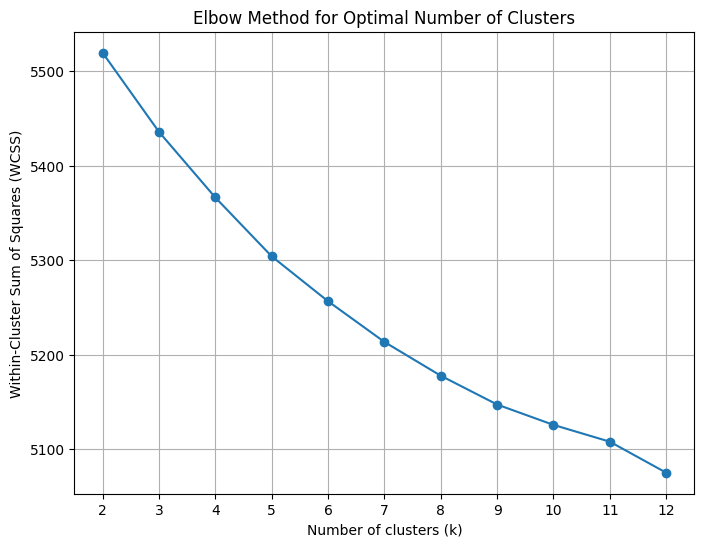

Saved: /content/drive/MyDrive/Epigenomics_corpus/topic_cluster_validation/Figure_Elbow_Method_KMeans.png
Saved: /content/drive/MyDrive/Epigenomics_corpus/topic_cluster_validation/Figure_Elbow_Method_KMeans.pdf


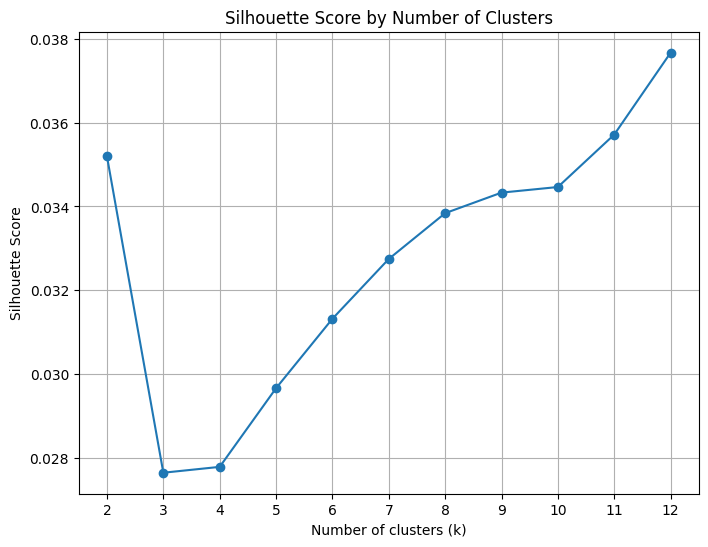

Saved: /content/drive/MyDrive/Epigenomics_corpus/topic_cluster_validation/Figure_Silhouette_Score_KMeans.png
Saved: /content/drive/MyDrive/Epigenomics_corpus/topic_cluster_validation/Figure_Silhouette_Score_KMeans.pdf


In [ ]:
# ============================================================
# 7. Elbow Method + Silhouette Score
# ============================================================
K_range = range(2, 13)

wcss = []
silhouette_scores = []

for k in K_range:
    print(f"Running KMeans for k={k}...")

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20,
        max_iter=300
    )

    labels = kmeans.fit_predict(X)

    wcss.append(kmeans.inertia_)

    sil_score = silhouette_score(X, labels)
    silhouette_scores.append(sil_score)

print("Completed.")

# ============================================================
# 8. Save validation results as CSV
# ============================================================
validation_df = pd.DataFrame({
    "k": list(K_range),
    "WCSS": wcss,
    "Silhouette_Score": silhouette_scores
})

csv_path = os.path.join(OUT_DIR, "kmeans_elbow_silhouette_results.csv")
validation_df.to_csv(csv_path, index=False, encoding="utf-8-sig")

validation_df

# ============================================================
# 9. Plot Elbow Method
# ============================================================
plt.figure(figsize=(8, 6))
plt.plot(list(K_range), wcss, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xticks(list(K_range))
plt.grid(True)

png_path = os.path.join(OUT_DIR, "Figure_Elbow_Method_KMeans.png")
pdf_path = os.path.join(OUT_DIR, "Figure_Elbow_Method_KMeans.pdf")

plt.savefig(png_path, dpi=600, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()

print("Saved:", png_path)
print("Saved:", pdf_path)

# ============================================================
# 10. Plot Silhouette Score
# ============================================================
plt.figure(figsize=(8, 6))
plt.plot(list(K_range), silhouette_scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")
plt.xticks(list(K_range))
plt.grid(True)

png_path = os.path.join(OUT_DIR, "Figure_Silhouette_Score_KMeans.png")
pdf_path = os.path.join(OUT_DIR, "Figure_Silhouette_Score_KMeans.pdf")

plt.savefig(png_path, dpi=600, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()

print("Saved:", png_path)
print("Saved:", pdf_path)

In [ ]:
# ============================================================
# 11. Final KMeans clustering with k=7
# ============================================================
final_k = 7

kmeans_final = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=20,
    max_iter=300
)

final_labels = kmeans_final.fit_predict(X)

cluster_df = pd.DataFrame({
    "file_name": file_names,
    "cluster": final_labels
})

cluster_csv_path = os.path.join(OUT_DIR, "kmeans_final_cluster_labels_k7.csv")
cluster_df.to_csv(cluster_csv_path, index=False, encoding="utf-8-sig")

cluster_df.head()

# ============================================================
# 12. Extract representative keywords for each cluster
# ============================================================
terms = vectorizer.get_feature_names_out()
centers = kmeans_final.cluster_centers_

top_n = 10
cluster_keywords = []

for i in range(final_k):
    top_indices = centers[i].argsort()[::-1][:top_n]
    keywords = [terms[idx] for idx in top_indices]

    n_docs = sum(final_labels == i)

    cluster_keywords.append({
        "Cluster": f"Cluster {i}",
        "Number of groups": n_docs,
        "Cluster words": ", ".join(keywords)
    })

table3_df = pd.DataFrame(cluster_keywords)

table3_path = os.path.join(OUT_DIR, "Table3_KMeans_Topic_Cluster_Composition_k7.csv")
table3_df.to_csv(table3_path, index=False, encoding="utf-8-sig")

table3_df

,Cluster,Number of groups,Cluster words
0,Cluster 0,722,"cancer, tumor, cells, mir, expression, patient..."
1,Cluster 1,610,"methylation, dna, cpg, dmrs, genes, methylated..."
2,Cluster 2,460,"plant, genome, genes, assembly, plants, specie..."
3,Cluster 3,895,"chromatin, seq, genome, genes, fig, enhancers,..."
4,Cluster 4,1734,"cells, fig, expression, rna, genes, figure, pr..."
5,Cluster 5,1461,"patients, fig, learning, figure, doi, risk, he..."
6,Cluster 6,268,"usepackage, document, upgreek, setlength, odds..."


Coherence Score, Silhouette Score

In [ ]:
# ============================================================
# Google Drive mount
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

# ============================================================
# 0. 라이브러리 설치
# ============================================================
!pip install gensim scikit-learn nltk

# ============================================================
# 1. 라이브러리 import
# ============================================================
import os
import re
import numpy as np
from tqdm import tqdm

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

from gensim import corpora
from gensim.models import LdaModel, CoherenceModel

from sklearn.metrics import silhouette_score

# ============================================================
# 2. 데이터 로드
# ============================================================
DATA_DIR = "/content/drive/MyDrive/Epigenomics_corpus/FullText_Epigenomics_data240126(최종)"

documents = []
for fname in tqdm(os.listdir(DATA_DIR)):
    if fname.endswith(".txt"):
        with open(os.path.join(DATA_DIR, fname), "r", encoding="utf-8", errors="ignore") as f:
            documents.append(f.read())

print("Loaded docs:", len(documents))

# ============================================================
# 3. 전처리
# ============================================================
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return tokens

texts = [preprocess(doc) for doc in documents]

# ============================================================
# 4. Dictionary & Corpus 생성
# ============================================================
dictionary = corpora.Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]

print("Dictionary size:", len(dictionary))

# ============================================================
# 5. LDA 모델 생성 (Table 3과 동일하게 topic=7)
# ============================================================
num_topics = 7

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=num_topics,
    random_state=42,
    passes=10
)

print("LDA model trained.")

# ============================================================
# 6. Document-Topic Matrix 생성
# ============================================================
doc_topics = []

for bow in corpus:
    topic_dist = lda_model.get_document_topics(bow, minimum_probability=0)
    vec = [prob for _, prob in topic_dist]
    doc_topics.append(vec)

doc_topics = np.array(doc_topics)

print("Doc-topic matrix shape:", doc_topics.shape)

# ============================================================
# 7. Silhouette Score 계산
# ============================================================
labels = np.argmax(doc_topics, axis=1)

sil_score = silhouette_score(doc_topics, labels)
print("Silhouette Score:", sil_score)

# ============================================================
# 8. Coherence Score 계산
# ============================================================
coherence_model = CoherenceModel(
    model=lda_model,
    texts=texts,
    dictionary=dictionary,
    coherence='c_v'
)

coherence_score = coherence_model.get_coherence()
print("Coherence Score:", coherence_score)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 21.8 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
100%|██████████| 6152/6152 [00:28<00:00, 216.72it/s]


Loaded docs: 6152
Dictionary size: 887518
LDA model trained.
Doc-topic matrix shape: (6152, 7)
Silhouette Score: 0.50389236
Coherence Score: 0.4679379613153009
